<a href="https://colab.research.google.com/github/grupos4g4/PROJAPLIC4/blob/main/projeto/cd_projeto_aplicado_IV_entrega_3_Editado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2025/02**


# **Entrega 3**

---

# **Título do Projeto**
---

In [ ]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Aluno 1, 123456789' #@param {type:"string"}
Aluno2 = 'Aluno 2, 123456789' #@param {type:"string"}
Aluno3 = 'Aluno 3, 123456789' #@param {type:"string"}
Aluno4 = 'Aluno 4, 123456789' #@param {type:"string"}
Aluno5 = 'Aluno 5, 123456789' #@param {type:"string"}


# **Introdução**

Juntar os tópicos de contexto, motivação, objetivo geral, objetivos específicos (incluir a bases de dados que será explorada) e justificativa em um único tópico.

# **Referencial Teórico**

(1 página) Defir resumidamente os principais conceitos envolvidos na sua solução. Discutir os trabalhos correlacionados. Apresentar alternativas de solução que foram empregadas no mesmo problema ou problemas semelhantes, e suas vantagens e limitações. Indicar referências ao longo do texto (padrão ABNT).



# **Diagrama de Solução**

Apresente e discuta o diagrama da solução proposta. Utilize o pipeline proposto inicialmente como base.

# **EDA e Pré-processamento dos dados**

Exploração e análise dos dados. Discussão e análise dos dados empregados (qualidade, limitações, simplicações ou recortes adotados etc.). Tarefas de preparação dos dados (transformações, compactação e encodes, junções de dados etc.).

In [1]:
# 🔼 Envie o arquivo dataset_inep.csv
from google.colab import files
import io, csv

uploaded = files.upload()  # selecione dataset_inep.csv
CSV_PATH = next((f"/content/{k}" for k in uploaded if k.endswith(".csv")), None)
assert CSV_PATH, "Envie o arquivo 'dataset_inep.csv'."

# Detecta o delimitador automaticamente (fallback ,)
with open(CSV_PATH, "rb") as f:
    sample = f.read(131072)
try:
    dialect = csv.Sniffer().sniff(sample.decode("latin-1", errors="ignore"))
    DELIM = dialect.delimiter
except Exception:
    DELIM = ","
print("Arquivo:", CSV_PATH, "| Delimitador detectado:", repr(DELIM))


KeyboardInterrupt: 

In [2]:
# 🗂️ Leitura direta do dataset INEP (sem upload manual)
import csv

# Informe o caminho completo para o arquivo CSV (exemplo abaixo para o Colab)
CAMINHO_CSV = "/content/dataset_inep.csv"  # ajuste conforme o local do seu arquivo

# Detecta automaticamente o delimitador (por exemplo, ',' ou ';')
with open(CAMINHO_CSV, "rb") as arquivo:
    amostra_bytes = arquivo.read(131072)

try:
    dialecto = csv.Sniffer().sniff(amostra_bytes.decode("latin-1", errors="ignore"))
    DELIMITADOR = dialecto.delimiter
except Exception:
    DELIMITADOR = ","

print("Arquivo localizado em:", CAMINHO_CSV)
print("Delimitador detectado:", repr(DELIMITADOR))


Arquivo localizado em: /content/dataset_inep.csv
Delimitador detectado: ','


In [4]:
# EDA + Pré-processamento (leitura robusta, normalização e agregação por ano)
import pandas as pd, numpy as np, re
from collections import defaultdict

# >>> ajuste estes dois se ainda não estiverem definidos na célula anterior:
# CAMINHO_CSV = "/content/dataset_inep.csv"
# DELIMITADOR = ","

def normalizar_nome_coluna(s: str) -> str:
    return re.sub(r"\s+", "_", s.strip().upper())

# Mapeia cabeçalho original -> nomes normalizados
with open(CAMINHO_CSV, "r", encoding="latin-1", errors="ignore") as f:
    cabecalho = f.readline().rstrip("\n")
colunas_originais = [c.strip() for c in cabecalho.split(DELIMITADOR)]
mapa_normalizados = {normalizar_nome_coluna(c): c for c in colunas_originais}

colunas_gerais = [
    "NU_ANO_CENSO","QT_MAT","QT_ING","QT_CONC",
    "QT_SIT_TRANCADA","QT_SIT_DESVINCULADO","QT_SIT_TRANSFERIDO","QT_SIT_FALECIDO",
    "QT_MAT_FEM","QT_MAT_MASC","QT_CONC_FEM","QT_CONC_MASC",
    "QT_MAT_0_17","QT_MAT_18_24","QT_MAT_25_29","QT_MAT_30_34","QT_MAT_35_39","QT_MAT_40_49","QT_MAT_50_59","QT_MAT_60_MAIS",
    "QT_CONC_0_17","QT_CONC_18_24","QT_CONC_25_29","QT_CONC_30_34","QT_CONC_35_39","QT_CONC_40_49","QT_CONC_50_59","QT_CONC_60_MAIS",
]
presentes_normalizados = [c for c in colunas_gerais if c in mapa_normalizados]
assert "NU_ANO_CENSO" in presentes_normalizados, "A coluna NU_ANO_CENSO é obrigatória."

colunas_para_uso = [mapa_normalizados[c] for c in presentes_normalizados]

# Acumuladores por ano
somas_por_ano        = defaultdict(lambda: defaultdict(float))
somas_por_ano_genero = defaultdict(lambda: defaultdict(float))
somas_por_ano_faixa  = defaultdict(lambda: defaultdict(float))

faixas_matricula   = ["QT_MAT_0_17","QT_MAT_18_24","QT_MAT_25_29","QT_MAT_30_34","QT_MAT_35_39","QT_MAT_40_49","QT_MAT_50_59","QT_MAT_60_MAIS"]
faixas_concluintes = ["QT_CONC_0_17","QT_CONC_18_24","QT_CONC_25_29","QT_CONC_30_34","QT_CONC_35_39","QT_CONC_40_49","QT_CONC_50_59","QT_CONC_60_MAIS"]

def adicionar_ao_acumulador(acumulador, ano, serie):
    for k, v in serie.items():
        if pd.notna(v):
            acumulador[ano][k] += float(v)

for pedaco in pd.read_csv(CAMINHO_CSV, sep=DELIMITADOR, usecols=colunas_para_uso, encoding="latin-1", chunksize=200_000):
    pedaco.columns = [normalizar_nome_coluna(c) for c in pedaco.columns]
    # Converte numéricos
    for c in pedaco.columns:
        if c.startswith("QT_") or c == "NU_ANO_CENSO":
            pedaco[c] = pd.to_numeric(pedaco[c], errors="coerce")
    pedaco = pedaco.dropna(subset=["NU_ANO_CENSO"])

    # Geral (Brasil)
    cols_geral = [c for c in ["QT_MAT","QT_ING","QT_CONC","QT_SIT_TRANCADA","QT_SIT_DESVINCULADO","QT_SIT_TRANSFERIDO","QT_SIT_FALECIDO"] if c in pedaco.columns]
    if cols_geral:
        grp = pedaco.groupby("NU_ANO_CENSO")[cols_geral].sum(numeric_only=True)
        for ano, linha in grp.iterrows():
            adicionar_ao_acumulador(somas_por_ano, int(ano), linha)

    # Gênero
    cols_genero = [c for c in ["QT_MAT_FEM","QT_MAT_MASC","QT_CONC_FEM","QT_CONC_MASC"] if c in pedaco.columns]
    if cols_genero:
        grp = pedaco.groupby("NU_ANO_CENSO")[cols_genero].sum(numeric_only=True)
        for ano, linha in grp.iterrows():
            adicionar_ao_acumulador(somas_por_ano_genero, int(ano), linha)

    # Faixa etária
    cols_faixa = [*([c for c in faixas_matricula if c in pedaco.columns]),
                  *([c for c in faixas_concluintes if c in pedaco.columns])]
    if cols_faixa:
        grp = pedaco.groupby("NU_ANO_CENSO")[cols_faixa].sum(numeric_only=True)
        for ano, linha in grp.iterrows():
            adicionar_ao_acumulador(somas_por_ano_faixa, int(ano), linha)

def construir_dataframe(acumulador):
    if not acumulador:
        return pd.DataFrame()
    anos = sorted(acumulador.keys())
    linhas = []
    for ano in anos:
        registro = {"NU_ANO_CENSO": ano}
        registro.update(acumulador[ano])
        linhas.append(registro)
    return pd.DataFrame(linhas).sort_values("NU_ANO_CENSO")

agregado_geral  = construir_dataframe(somas_por_ano)
agregado_genero = construir_dataframe(somas_por_ano_genero)
agregado_faixa  = construir_dataframe(somas_por_ano_faixa)

print("Anos encontrados:", list(agregado_geral["NU_ANO_CENSO"]) if not agregado_geral.empty else "—")
display(agregado_geral.head())


Anos encontrados: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,NU_ANO_CENSO,QT_MAT,QT_ING,QT_SIT_TRANCADA,QT_SIT_DESVINCULADO,QT_SIT_TRANSFERIDO,QT_SIT_FALECIDO
0,2014,7839765.0,3114510.0,1211342.0,1632828.0,108796.0,1204.0
1,2015,8033574.0,2922400.0,1303873.0,1738763.0,109858.0,1228.0
2,2016,8052254.0,2986636.0,1257239.0,2032235.0,106311.0,1183.0
3,2017,8290911.0,3226906.0,1295524.0,1904921.0,96532.0,1306.0
4,2018,8451748.0,3446328.0,1290433.0,2193185.0,107435.0,1192.0


In [6]:
# Cálculo de taxas de evasão (Brasil, gênero e faixa etária) — variáveis em português
import pandas as pd

def calcular_evasao_brasil(agregado: pd.DataFrame):
    tem_conc   = all(c in agregado.columns for c in ["QT_MAT","QT_CONC"])
    tem_status = all(c in agregado.columns for c in ["QT_MAT","QT_SIT_TRANCADA","QT_SIT_DESVINCULADO","QT_SIT_TRANSFERIDO","QT_SIT_FALECIDO"])
    tem_proxy  = all(c in agregado.columns for c in ["QT_MAT","QT_ING"])

    if tem_conc:
        saida = agregado[["NU_ANO_CENSO","QT_MAT","QT_CONC"]].copy()
        saida["TAXA_EVASAO"] = (saida["QT_MAT"] - saida["QT_CONC"]) / saida["QT_MAT"]
        return saida, "QT_MAT e QT_CONC (padrão)"

    if tem_status:
        saida = agregado[["NU_ANO_CENSO","QT_MAT","QT_SIT_TRANCADA","QT_SIT_DESVINCULADO","QT_SIT_TRANSFERIDO","QT_SIT_FALECIDO"]].copy()
        saida["EVASAO_STATUS"] = saida[["QT_SIT_TRANCADA","QT_SIT_DESVINCULADO","QT_SIT_TRANSFERIDO","QT_SIT_FALECIDO"]].sum(axis=1, min_count=1)
        saida["TAXA_EVASAO"]   = saida["EVASAO_STATUS"] / saida["QT_MAT"]
        saida = saida[["NU_ANO_CENSO","QT_MAT","TAXA_EVASAO"]]
        return saida, "proxy por status (tranc./desvinc./transf./óbito)"

    if tem_proxy:
        saida = agregado[["NU_ANO_CENSO","QT_MAT","QT_ING"]].copy().sort_values("NU_ANO_CENSO")
        saida["TAXA_EVASAO"] = 1 - (saida["QT_MAT"].shift(-1) - saida["QT_ING"].shift(-1)) / saida["QT_MAT"]
        saida = saida.dropna(subset=["TAXA_EVASAO"])
        return saida, "proxy de coorte: 1 - (QT_MAT[t+1]-QT_ING[t+1]) / QT_MAT[t]"

    raise RuntimeError("Colunas insuficientes para calcular evasão anual (Brasil).")

def calcular_evasao_genero(agregado_genero: pd.DataFrame):
    precisa = ["QT_MAT_FEM","QT_MAT_MASC","QT_CONC_FEM","QT_CONC_MASC"]
    if all(c in agregado_genero.columns for c in precisa):
        g = agregado_genero[["NU_ANO_CENSO"] + precisa].copy()
        saida = g[["NU_ANO_CENSO"]].copy()
        saida["TAXA_EVASAO_FEM"]  = (g["QT_MAT_FEM"]  - g["QT_CONC_FEM"])  / g["QT_MAT_FEM"]
        saida["TAXA_EVASAO_MASC"] = (g["QT_MAT_MASC"] - g["QT_CONC_MASC"]) / g["QT_MAT_MASC"]
        return saida, "QT_MAT_* e QT_CONC_* (padrão)"
    return pd.DataFrame(), "indisponível (faltam QT_CONC_* por gênero)"

def calcular_evasao_faixa(agregado_faixa: pd.DataFrame):
    mm = ["QT_MAT_0_17","QT_MAT_18_24","QT_MAT_25_29","QT_MAT_30_34","QT_MAT_35_39","QT_MAT_40_49","QT_MAT_50_59","QT_MAT_60_MAIS"]
    cc = ["QT_CONC_0_17","QT_CONC_18_24","QT_CONC_25_29","QT_CONC_30_34","QT_CONC_35_39","QT_CONC_40_49","QT_CONC_50_59","QT_CONC_60_MAIS"]
    if all(c in agregado_faixa.columns for c in mm + cc):
        rotulos = ['0_17','18_24','25_29','30_34','35_39','40_49','50_59','60_MAIS']
        dados = {"NU_ANO_CENSO": agregado_faixa["NU_ANO_CENSO"]}
        for rot, m, c in zip(rotulos, mm, cc):
            dados[f"TAXA_EVASAO_{rot}"] = (agregado_faixa[m] - agregado_faixa[c]) / agregado_faixa[m]
        return pd.DataFrame(dados), "QT_MAT_* e QT_CONC_* por faixa (padrão)"
    return pd.DataFrame(), "indisponível (faltam QT_CONC_* por faixa)"

# ==== chamadas com os dataframes agregados (coerentes com a etapa anterior) ====
evasao_brasil_df, fonte_brasil = calcular_evasao_brasil(agregado_geral)
evasao_genero_df, fonte_genero = calcular_evasao_genero(agregado_genero)
evasao_faixa_df,  fonte_faixa  = calcular_evasao_faixa(agregado_faixa)

print("Fonte evasão Brasil:",  fonte_brasil);  display(evasao_brasil_df.head(12))
print("Fonte evasão por gênero:", fonte_genero); display(evasao_genero_df.head(12) if not evasao_genero_df.empty else evasao_genero_df)
print("Fonte evasão por faixa:",  fonte_faixa);  display(evasao_faixa_df.head(12)  if not evasao_faixa_df.empty else evasao_faixa_df)


Fonte evasão Brasil: proxy por status (tranc./desvinc./transf./óbito)


,NU_ANO_CENSO,QT_MAT,TAXA_EVASAO
0,2014,7839765.0,0.376819
1,2015,8033574.0,0.392568
2,2016,8052254.0,0.421865
3,2017,8290911.0,0.397819
4,2018,8451748.0,0.425030
5,2019,8604526.0,0.435388
6,2020,8680945.0,0.447510
7,2021,8987120.0,0.469339
8,2022,9444116.0,0.524705
9,2023,9977217.0,0.523185


Fonte evasão por gênero: indisponível (faltam QT_CONC_* por gênero)


""


Fonte evasão por faixa: indisponível (faltam QT_CONC_* por faixa)


""


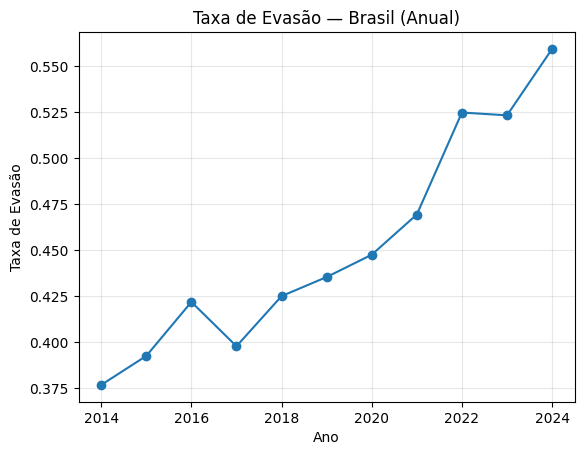

Arquivos e gráficos salvos em: /content/entrega3_saidas


In [8]:
# Exporta resultados da EDA e das séries temporais de evasão
import os
import matplotlib.pyplot as plt

# Define a pasta de saída
PASTA_SAIDA = "/content/entrega3_saidas"
os.makedirs(PASTA_SAIDA, exist_ok=True)

# Exporta arquivos CSV
evasao_brasil_df.to_csv(f"{PASTA_SAIDA}/taxa_evasao_brasil_ano.csv", index=False, encoding="utf-8")

if not evasao_genero_df.empty:
    evasao_genero_df.to_csv(f"{PASTA_SAIDA}/taxa_evasao_genero_ano.csv", index=False, encoding="utf-8")

if not evasao_faixa_df.empty:
    evasao_faixa_df.to_csv(f"{PASTA_SAIDA}/taxa_evasao_faixa_ano.csv", index=False, encoding="utf-8")

agregado_geral.to_csv(f"{PASTA_SAIDA}/_somas_por_ano.csv", index=False, encoding="utf-8")

# Geração dos gráficos de evasão
plt.figure()
plt.plot(evasao_brasil_df["NU_ANO_CENSO"], evasao_brasil_df["TAXA_EVASAO"], marker='o')
plt.title("Taxa de Evasão — Brasil (Anual)")
plt.xlabel("Ano")
plt.ylabel("Taxa de Evasão")
plt.grid(True, alpha=0.3)
plt.savefig(f"{PASTA_SAIDA}/grafico_evasao_brasil.png", dpi=150, bbox_inches="tight")
plt.show()

# Gráfico por gênero
if not evasao_genero_df.empty:
    plt.figure()
    plt.plot(evasao_genero_df["NU_ANO_CENSO"], evasao_genero_df["TAXA_EVASAO_FEM"],  label="Feminino", marker='o')
    plt.plot(evasao_genero_df["NU_ANO_CENSO"], evasao_genero_df["TAXA_EVASAO_MASC"], label="Masculino", marker='s')
    plt.title("Taxa de Evasão — por Gênero")
    plt.xlabel("Ano")
    plt.ylabel("Taxa de Evasão")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(f"{PASTA_SAIDA}/grafico_evasao_genero.png", dpi=150, bbox_inches="tight")
    plt.show()

# Gráficos por faixa etária
if not evasao_faixa_df.empty:
    for coluna in evasao_faixa_df.columns:
        if coluna.startswith("TAXA_EVASAO_"):
            plt.figure()
            plt.plot(evasao_faixa_df["NU_ANO_CENSO"], evasao_faixa_df[coluna], marker='o')
            plt.title(f"Taxa de Evasão — Faixa Etária {coluna.replace('TAXA_EVASAO_', '').replace('_', ' a ')}")
            plt.xlabel("Ano")
            plt.ylabel("Taxa de Evasão")
            plt.grid(True, alpha=0.3)
            plt.savefig(f"{PASTA_SAIDA}/grafico_{coluna}.png", dpi=150, bbox_inches="tight")
            plt.show()

print("Arquivos e gráficos salvos em:", PASTA_SAIDA)


In [ ]:
# Códigos aqui

# **Modelo base**

Aplicação de, pelo menos, um primeiro modelo (modelo de aprendizado de máquina ou modelo estatístico) que deve ser refinado até a entrega final do projeto. Apresente o método aplicado e a análise dos resultados obtidos.

Previsão ETS (10 anos):


,0
2025,0.556238
2026,0.573589
2027,0.590940
2028,0.608291
2029,0.625641
2030,0.642992
2031,0.660343
2032,0.677694
2033,0.695045
2034,0.712396


Previsão SARIMAX(1,1,0) (10 anos):


,0
2025,0.564126
2026,0.564789
2027,0.564879
2028,0.564891
2029,0.564893
2030,0.564893
2031,0.564893
2032,0.564893
2033,0.564893
2034,0.564893


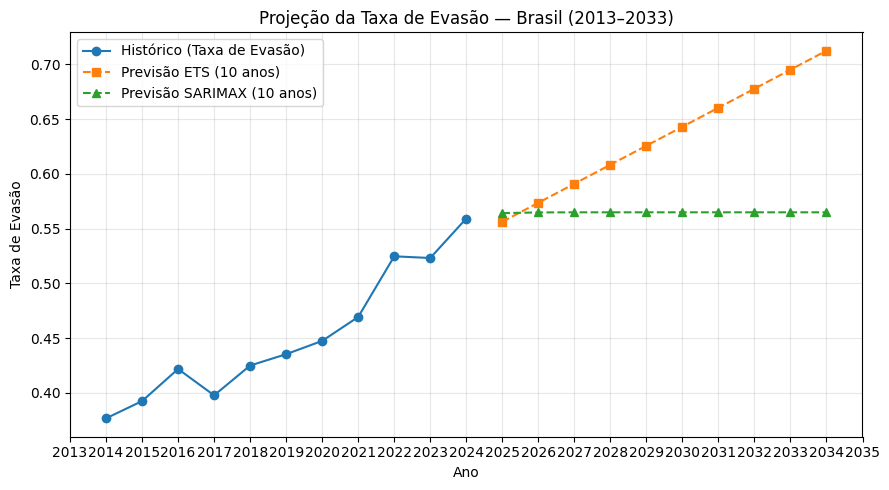

In [15]:
# Modelo base — ETS e SARIMAX (previsão para 10 anos com anos reais)
import warnings as avisos
avisos.filterwarnings("ignore")

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd

# Série alvo (Taxa de evasão anual no Brasil)
serie_anual = (
    evasao_brasil_df
    .dropna(subset=["TAXA_EVASAO"])
    .set_index("NU_ANO_CENSO")["TAXA_EVASAO"]
    .sort_index()
)

# Último ano presente nos dados
ultimo_ano = serie_anual.index.max()

# Gera lista de anos futuros para o horizonte de 10 anos
anos_futuros = pd.Index(range(ultimo_ano + 1, ultimo_ano + 11))

# Modelo ETS (tendência aditiva, sem sazonalidade)
modelo_ets = ExponentialSmoothing(
    serie_anual,
    trend="add",
    seasonal=None
).fit(optimized=True)

previsao_ets_10 = pd.Series(modelo_ets.forecast(10).values, index=anos_futuros)

# Modelo SARIMAX (1,1,0)
modelo_sarimax = SARIMAX(
    serie_anual,
    order=(1, 1, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

previsao_sarimax_10 = pd.Series(modelo_sarimax.forecast(10).values, index=anos_futuros)

# Exibe previsões
print("Previsão ETS (10 anos):")
display(previsao_ets_10)

print("Previsão SARIMAX(1,1,0) (10 anos):")
display(previsao_sarimax_10)

# Visualização comparativa com eixo X mostrando anos inteiros
import matplotlib.ticker as ticker

# Visualização comparativa
plt.figure(figsize=(9,5))
plt.plot(serie_anual.index, serie_anual, label="Histórico (Taxa de Evasão)", marker='o')
plt.plot(previsao_ets_10.index, previsao_ets_10, label="Previsão ETS (10 anos)", linestyle="--", marker='s')
plt.plot(previsao_sarimax_10.index, previsao_sarimax_10, label="Previsão SARIMAX (10 anos)", linestyle="--", marker='^')
plt.title("Projeção da Taxa de Evasão — Brasil (2013–2033)")
plt.xlabel("Ano")
plt.ylabel("Taxa de Evasão")
plt.grid(True, alpha=0.3)
plt.legend()
# 🔧 Força o eixo X a mostrar apenas anos inteiros
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))

plt.tight_layout()
plt.show()


Previsão ETS (10 anos):


,0
11,0.556238
12,0.573589
13,0.590940
14,0.608291
15,0.625641
16,0.642992
17,0.660343
18,0.677694
19,0.695045
20,0.712396


Previsão SARIMAX(1,1,0) (10 anos):


,predicted_mean
11,0.564126
12,0.564789
13,0.564879
14,0.564891
15,0.564893
16,0.564893
17,0.564893
18,0.564893
19,0.564893
20,0.564893


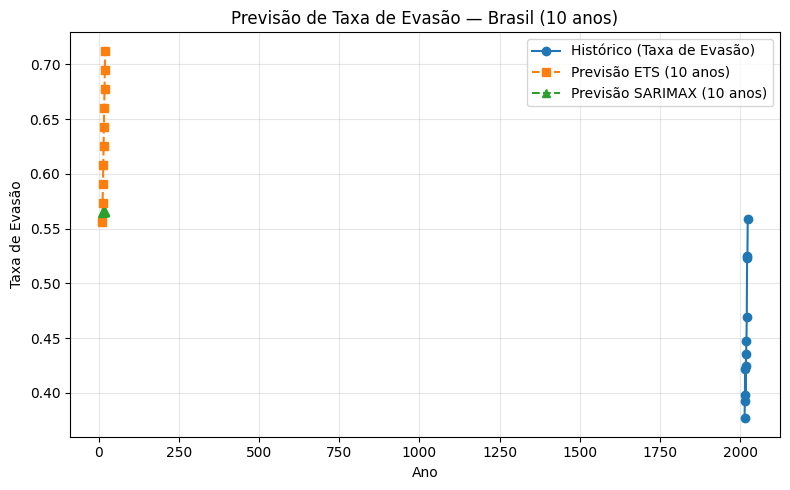

In [11]:
# Modelo base — ETS e SARIMAX (previsão para 10 anos)
import warnings as avisos
avisos.filterwarnings("ignore")

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Série alvo (Taxa de evasão anual no Brasil)
serie_anual = (
    evasao_brasil_df
    .dropna(subset=["TAXA_EVASAO"])
    .set_index("NU_ANO_CENSO")["TAXA_EVASAO"]
    .sort_index()
)

# ETS — modelo de suavização exponencial com tendência aditiva (sem sazonalidade)
modelo_ets = ExponentialSmoothing(
    serie_anual,
    trend="add",
    seasonal=None
).fit(optimized=True)

previsao_ets_10 = modelo_ets.forecast(10)  # 10 anos à frente

# SARIMAX — modelo autoregressivo integrado de média móvel simples (1,1,0)
modelo_sarimax = SARIMAX(
    serie_anual,
    order=(1, 1, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

previsao_sarimax_10 = modelo_sarimax.forecast(10)  # 10 anos à frente

# Exibe previsões
print("Previsão ETS (10 anos):")
display(previsao_ets_10)

print("Previsão SARIMAX(1,1,0) (10 anos):")
display(previsao_sarimax_10)

# Visualização comparativa
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(serie_anual.index, serie_anual, label="Histórico (Taxa de Evasão)", marker='o')
plt.plot(previsao_ets_10.index, previsao_ets_10, label="Previsão ETS (10 anos)", linestyle="--", marker='s')
plt.plot(previsao_sarimax_10.index, previsao_sarimax_10, label="Previsão SARIMAX (10 anos)", linestyle="--", marker='^')
plt.title("Previsão de Taxa de Evasão — Brasil (10 anos)")
plt.xlabel("Ano")
plt.ylabel("Taxa de Evasão")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Modelo base — ETS e SARIMAX (simples)
import warnings as avisos
avisos.filterwarnings("ignore")

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Série alvo (evasão Brasil anual)
serie_anual = (
    evasao_brasil_df
    .dropna(subset=["TAXA_EVASAO"])
    .set_index("NU_ANO_CENSO")["TAXA_EVASAO"]
    .sort_index()
)

# ETS (sem sazonalidade; tendência aditiva)
modelo_ets = ExponentialSmoothing(serie_anual, trend="add", seasonal=None).fit(optimized=True)
previsao_ets = modelo_ets.forecast(3)

# SARIMAX simples (1,1,0) sem sazonalidade
modelo_sarimax = SARIMAX(
    serie_anual, order=(1, 1, 0),
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
previsao_sarimax = modelo_sarimax.forecast(3)

print("Previsão ETS (3 anos):")
display(previsao_ets)

print("Previsão SARIMAX(1,1,0) (3 anos):")
display(previsao_sarimax)


Previsão ETS (3 anos):


,0
11,0.556238
12,0.573589
13,0.590940


Previsão SARIMAX(1,1,0) (3 anos):


,predicted_mean
11,0.564126
12,0.564789
13,0.564879


In [ ]:
# Códigos aqui

In [17]:
serie_anual = (evasao_brasil_df.dropna(subset=["TAXA_EVASAO"])
               .set_index("NU_ANO_CENSO")["TAXA_EVASAO"].sort_index())


,ETS,"SARIMAX(1, 0, 0)"
ANO,,
2025,0.556238,0.582379
2026,0.573589,0.606480
2027,0.590940,0.631578
2028,0.608291,0.657716
2029,0.625641,0.684934
2030,0.642992,0.713280
2031,0.660343,0.742798
2032,0.677694,0.773538
2033,0.695045,0.805550


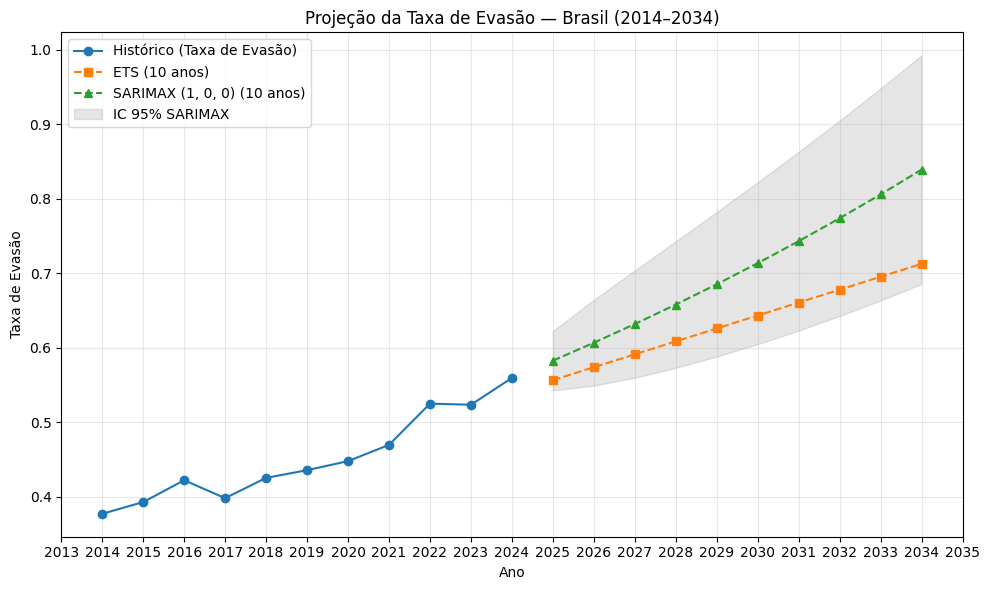

Melhor ordem SARIMAX (AIC): (1, 0, 0)  AIC: -45.5
Arquivos salvos em: /content/entrega3_saidas


In [20]:
# ===== ETS + Auto-SARIMAX (com IC)
import warnings as avisos
avisos.filterwarnings("ignore")

import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

if 'PASTA_SAIDA' not in globals():
    PASTA_SAIDA = "/content/entrega3_saidas"
os.makedirs(PASTA_SAIDA, exist_ok=True)

# serie_anual já definida antes:
# serie_anual = (evasao_brasil_df.dropna(subset=["TAXA_EVASAO"])
#                .set_index("NU_ANO_CENSO")["TAXA_EVASAO"].sort_index())

horizonte = 10
ultimo_ano = int(serie_anual.index.max())
anos_futuros = pd.Index(range(ultimo_ano + 1, ultimo_ano + 1 + horizonte))

# --- ETS (trend add) com IC aproximado via simulação residual simples ---
modelo_ets = ExponentialSmoothing(serie_anual, trend="add", seasonal=None).fit(optimized=True)
fc_ets_vals = modelo_ets.forecast(horizonte).values
previsao_ets_10 = pd.Series(fc_ets_vals, index=anos_futuros, name="ETS")

# --- Auto-SARIMAX via grid pequeno (sem pmdarima) ---
def auto_sarimax_grid(y, p_max=2, d_vals=(0,1), q_max=2):
    melhor_aic = np.inf
    melhor_ordem, melhor_modelo = None, None
    for d in d_vals:
        for p in range(p_max+1):
            for q in range(q_max+1):
                if p == q == d == 0:
                    continue
                try:
                    m = SARIMAX(y, order=(p,d,q),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if m.aic < melhor_aic:
                        melhor_aic = m.aic
                        melhor_ordem, melhor_modelo = (p,d,q), m
                except Exception:
                    pass
    return melhor_modelo, melhor_ordem, melhor_aic

modelo_sarimax_auto, ordem_auto, aic_auto = auto_sarimax_grid(serie_anual, p_max=3, d_vals=(0,1), q_max=3)
if modelo_sarimax_auto is None:
    modelo_sarimax_auto = SARIMAX(serie_anual, order=(1,1,0),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False).fit(disp=False)
    ordem_auto = (1,1,0)

# Forecast com IC
fc = modelo_sarimax_auto.get_forecast(steps=horizonte)
previsao_sarimax_10 = pd.Series(fc.predicted_mean.values, index=anos_futuros, name=f"SARIMAX{ordem_auto}")
ic_sarimax = fc.conf_int(alpha=0.05)  # 95%
ic_sarimax.index = anos_futuros
ic_inf = ic_sarimax.iloc[:,0]
ic_sup = ic_sarimax.iloc[:,1]

# Consolida e exporta
previsoes = pd.concat([previsao_ets_10, previsao_sarimax_10], axis=1)
previsoes.index.name = "ANO"
previsoes.to_csv(f"{PASTA_SAIDA}/previsoes_10_anos_sem_prophet.csv", encoding="utf-8")
display(previsoes.head(10))

# Gráfico com eixo X inteiro e IC do SARIMAX
plt.figure(figsize=(10,6))
plt.plot(serie_anual.index, serie_anual, label="Histórico (Taxa de Evasão)", marker='o')
plt.plot(previsao_ets_10.index, previsao_ets_10, label="ETS (10 anos)", linestyle="--", marker='s')
plt.plot(previsao_sarimax_10.index, previsao_sarimax_10, label=f"SARIMAX {ordem_auto} (10 anos)", linestyle="--", marker='^')
plt.fill_between(previsao_sarimax_10.index, ic_inf, ic_sup, color='gray', alpha=0.2, label="IC 95% SARIMAX")

plt.title(f"Projeção da Taxa de Evasão — Brasil ({int(serie_anual.index.min())}–{anos_futuros.max()})")
plt.xlabel("Ano"); plt.ylabel("Taxa de Evasão"); plt.grid(True, alpha=0.3); plt.legend()
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/comparativo_ets_sarimax_com_ic.png", dpi=150, bbox_inches="tight")
plt.show()

print("Melhor ordem SARIMAX (AIC):", ordem_auto, " AIC:", round(aic_auto,2))
print("Arquivos salvos em:", PASTA_SAIDA)


In [19]:
# ============================================
# ETS + Auto-SARIMAX (grid com statsmodels) + Prophet (opcional)
# ============================================
import warnings as avisos
avisos.filterwarnings("ignore")

import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Garante pasta de saída
if 'PASTA_SAIDA' not in globals():
    PASTA_SAIDA = "/content/entrega3_saidas"
os.makedirs(PASTA_SAIDA, exist_ok=True)

# Série alvo (já definida antes no notebook)
# serie_anual = (evasao_brasil_df.dropna(subset=["TAXA_EVASAO"])
#                .set_index("NU_ANO_CENSO")["TAXA_EVASAO"].sort_index())

horizonte = 10
ultimo_ano = int(serie_anual.index.max())
anos_futuros = pd.Index(range(ultimo_ano + 1, ultimo_ano + 1 + horizonte))

# ---------------------------
# ETS (tendência aditiva)
# ---------------------------
modelo_ets = ExponentialSmoothing(serie_anual, trend="add", seasonal=None).fit(optimized=True)
previsao_ets_10 = pd.Series(modelo_ets.forecast(horizonte).values, index=anos_futuros, name="ETS")

# ----------------------------------------------------
# Auto-SARIMAX via grid search (sem pmdarima)
# ----------------------------------------------------
def auto_sarimax_grid(y, p_max=2, d_vals=(0,1), q_max=2):
    """Busca simples pela menor AIC em SARIMAX(p,d,q) sem sazonalidade."""
    melhor_aic = np.inf
    melhor_orden = None
    melhor_modelo = None
    for d in d_vals:
        for p in range(p_max+1):
            for q in range(q_max+1):
                if p == q == d == 0:
                    continue
                try:
                    m = SARIMAX(y, order=(p,d,q),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)
                    if m.aic < melhor_aic:
                        melhor_aic = m.aic
                        melhor_orden = (p,d,q)
                        melhor_modelo = m
                except Exception:
                    pass
    return melhor_modelo, melhor_orden, melhor_aic

modelo_sarimax_auto, ordem_auto, aic_auto = auto_sarimax_grid(serie_anual, p_max=2, d_vals=(0,1), q_max=2)
if modelo_sarimax_auto is None:
    # fallback muito simples
    modelo_sarimax_auto = SARIMAX(serie_anual, order=(1,1,0),
                                  enforce_stationarity=False,
                                  enforce_invertibility=False).fit(disp=False)
    ordem_auto = (1,1,0)

previsao_sarimax_auto_10 = pd.Series(modelo_sarimax_auto.forecast(horizonte).values,
                                     index=anos_futuros,
                                     name=f"SARIMAX{ordem_auto}")

# ---------------------------
# Prophet (opcional)
# ---------------------------
tem_prophet = False
try:
    from prophet import Prophet
    tem_prophet = True
except Exception:
    try:
        %pip -q install prophet
        from prophet import Prophet
        tem_prophet = True
    except Exception:
        print("[Aviso] Prophet não foi instalado. Seguiremos sem ele.")

if tem_prophet:
    df_prophet = pd.DataFrame({
        "ds": pd.to_datetime(serie_anual.index.astype(str) + "-01-01"),
        "y": serie_anual.values
    })
    modelo_prophet = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    modelo_prophet.fit(df_prophet)
    futuro = modelo_prophet.make_future_dataframe(periods=horizonte, freq="Y")
    prev_prophet_df = modelo_prophet.predict(futuro)
    prev_prophet_df["ANO"] = prev_prophet_df["ds"].dt.year
    previsao_prophet_10 = prev_prophet_df[prev_prophet_df["ANO"].isin(anos_futuros)][["ANO","yhat"]]
    previsao_prophet_10 = previsao_prophet_10.set_index("ANO")["yhat"]
    previsao_prophet_10.name = "Prophet"
else:
    previsao_prophet_10 = None

# ---------------------------
# Consolida e exporta
# ---------------------------
previsoes_lista = [previsao_ets_10, previsao_sarimax_auto_10]
if previsao_prophet_10 is not None:
    previsoes_lista.append(previsao_prophet_10)

previsoes = pd.concat(previsoes_lista, axis=1)
previsoes.index.name = "ANO"
previsoes.to_csv(f"{PASTA_SAIDA}/previsoes_10_anos.csv", encoding="utf-8")
display(previsoes)

# ---------------------------
# Gráfico com anos inteiros
# ---------------------------
plt.figure(figsize=(10,6))
plt.plot(serie_anual.index, serie_anual, label="Histórico (Taxa de Evasão)", marker='o')
plt.plot(previsao_ets_10.index, previsao_ets_10, label="ETS (10 anos)", linestyle="--", marker='s')
plt.plot(previsao_sarimax_auto_10.index, previsao_sarimax_auto_10, label=f"SARIMAX {ordem_auto} (10 anos)", linestyle="--", marker='^')
if previsao_prophet_10 is not None:
    plt.plot(previsao_prophet_10.index, previsao_prophet_10, label="Prophet (10 anos)", linestyle="--", marker='x')

plt.title(f"Projeção da Taxa de Evasão — Brasil ({int(serie_anual.index.min())}–{anos_futuros.max()})")
plt.xlabel("Ano"); plt.ylabel("Taxa de Evasão"); plt.grid(True, alpha=0.3); plt.legend()
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/comparativo_previsoes_10_anos.png", dpi=150, bbox_inches="tight")
plt.show()

print("Melhor ordem SARIMAX (AIC):", ordem_auto, aic_auto)
print("Arquivos salvos em:", PASTA_SAIDA)


AttributeError: 'Prophet' object has no attribute 'stan_backend'

# **Cronograma**

Atualizar o cronograma, se necessário, das atividades.

# **Referências**

Complementar a entrega anterior.




In [ ]:
#@title **Avaliação**
EDA_e_preprocessamento = 10 #@param {type:"slider", min:0, max:10, step:1}

Modelo_base = 10 #@param {type:"slider", min:0, max:10, step:1}

In [ ]:
#@title **Nota Final**
nota = 0.50*EDA_e_preprocessamento + 0.50*Modelo_base

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Aluno 1,10.0
1,Aluno 2,10.0
2,Aluno 3,10.0
3,Aluno 4,10.0
4,Aluno 5,10.0
